# MLP — Planetary Image Classification

**Project:** Can Neural Networks Reliably Differentiate Planetary Images — or Do They Learn Dataset Bias?

**Dataset:** [Planets and Moons Dataset - AI in Space](https://www.kaggle.com/datasets/emirhanai/planets-and-moons-dataset-ai-in-space) (11 classes, ~149 images each)

**Model:** Multi-Layer Perceptron (MLP)

This notebook covers:
- Baseline MLP with ReLU + Cross-Entropy
- Activation function comparison: ReLU vs Sigmoid vs Tanh
- Depth vs Width — capacity and bias-variance tradeoff
- Regularization: L2 weight decay, Dropout, Batch Normalization, Early Stopping
- Optimizer comparison: SGD vs SGD+Momentum vs Adam
- Best combination of all techniques
- Confusion matrix and bias analysis

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import json

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [2]:
# config
DATA_DIR = "../datasets/Planets and Moons/"   # path to dataset
IMG_SIZE = 256
BATCH_SIZE = 32
SEED = 42
EPOCHS = 60

torch.manual_seed(SEED)
np.random.seed(SEED)

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

input_dim = 3 * IMG_SIZE * IMG_SIZE
print(f"Input dim: {input_dim:,}  ({IMG_SIZE}x{IMG_SIZE}x3)")

os.makedirs("../results/mlp", exist_ok=True)
os.makedirs("../models/mlp", exist_ok=True)

Using device: mps
Input dim: 196,608  (256x256x3)


In [3]:
# transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [4]:
# load full dataset to get labels for stratified split
full_dataset = datasets.ImageFolder(DATA_DIR)
targets = np.array(full_dataset.targets)
class_names = full_dataset.classes
num_classes = len(class_names)

print(f"Classes ({num_classes}): {class_names}")
print(f"Total images: {len(full_dataset)}")

Classes (11): ['Earth', 'Jupiter', 'MakeMake', 'Mars', 'Mercury', 'Moon', 'Neptune', 'Pluto', 'Saturn', 'Uranus', 'Venus']
Total images: 1638


In [5]:
# stratified 70/15/15 split
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(sss1.split(np.zeros(len(targets)), targets))

temp_targets = targets[temp_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_rel, test_rel = next(sss2.split(np.zeros(len(temp_targets)), temp_targets))
val_idx = temp_idx[val_rel]
test_idx = temp_idx[test_rel]

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

Train: 1146, Val: 246, Test: 246


In [6]:
# create dataloaders
train_ds = datasets.ImageFolder(DATA_DIR, transform=train_transform)
eval_ds = datasets.ImageFolder(DATA_DIR, transform=test_transform)

train_loader = DataLoader(Subset(train_ds, train_idx), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(Subset(eval_ds, val_idx), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(Subset(eval_ds, test_idx), batch_size=BATCH_SIZE, shuffle=False)

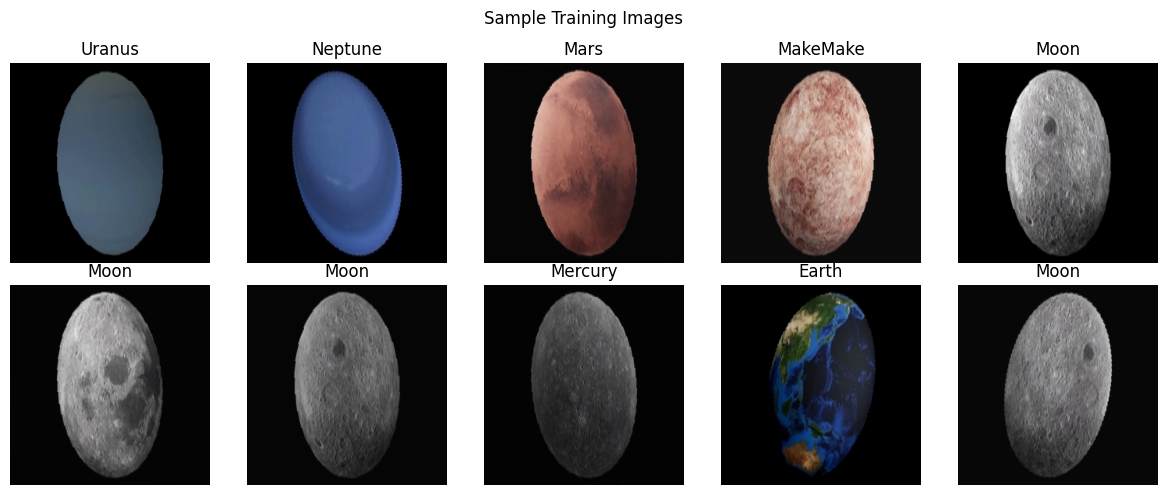

In [7]:
# show some sample images
imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = imgs[i].permute(1, 2, 0).numpy()  # already [0, 1] from ToTensor()
    ax.imshow(img)
    ax.set_title(class_names[labels[i]])
    ax.axis("off")
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()

In [8]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, num_classes, activation="relu",
                 dropout=0.0, use_bn=False):
        super().__init__()
        
        # pick activation
        if activation == "relu":
            act = nn.ReLU()
        elif activation == "sigmoid":
            act = nn.Sigmoid()
        elif activation == "tanh":
            act = nn.Tanh()
        
        layers = []
        prev = input_dim
        for h in hidden_layers:
            layers.append(nn.Linear(prev, h))
            if use_bn:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act)
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        return self.net(x)

In [9]:
# quick test
model = MLP(input_dim, [512, 256], num_classes)
print(model)
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=196608, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=11, bias=True)
  )
)
Total params: 100,797,963


In [10]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)

In [11]:
def train_model(model, epochs=60, lr=1e-3, weight_decay=0, optimizer_type="adam", patience=10):
    """Train with early stopping. Returns history dict."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    
    if optimizer_type == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type == "sgd_momentum":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    best_weights = None
    wait = 0
    
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        # early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
        
        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
                  f"train_acc={train_acc:.3f}  val_acc={val_acc:.3f}")
        
        if wait >= patience:
            print(f"  Early stopping at epoch {epoch}")
            break
    
    # load best weights
    model.load_state_dict(best_weights)
    return history

In [12]:
def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(history["train_loss"], label="Train")
    ax1.plot(history["val_loss"], label="Val")
    ax1.set_title(f"Loss {title}"); ax1.legend(); ax1.grid(True, alpha=0.3)
    
    ax2.plot(history["train_acc"], label="Train")
    ax2.plot(history["val_acc"], label="Val")
    ax2.set_title(f"Accuracy {title}"); ax2.legend(); ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 5. Experiment 1 — Baseline MLP

Simple 2-layer MLP with ReLU activation and cross-entropy loss. No regularization.

This is our starting point to see how a basic feedforward network performs on this dataset.

EXPERIMENT 1: Baseline MLP [512, 256]
  Epoch   1  train_loss=4.3547  val_loss=1.3456  train_acc=0.321  val_acc=0.496
  Epoch  10  train_loss=0.2907  val_loss=0.2465  train_acc=0.887  val_acc=0.915
  Epoch  20  train_loss=0.2029  val_loss=0.1644  train_acc=0.918  val_acc=0.923
  Epoch  30  train_loss=0.1248  val_loss=0.0826  train_acc=0.949  val_acc=0.963
  Epoch  40  train_loss=0.0913  val_loss=0.0896  train_acc=0.964  val_acc=0.959
  Epoch  50  train_loss=0.0914  val_loss=0.1439  train_acc=0.968  val_acc=0.931
  Epoch  60  train_loss=0.0251  val_loss=0.0059  train_acc=0.995  val_acc=1.000

  Test Accuracy: 1.0000   Macro F1: 1.0000


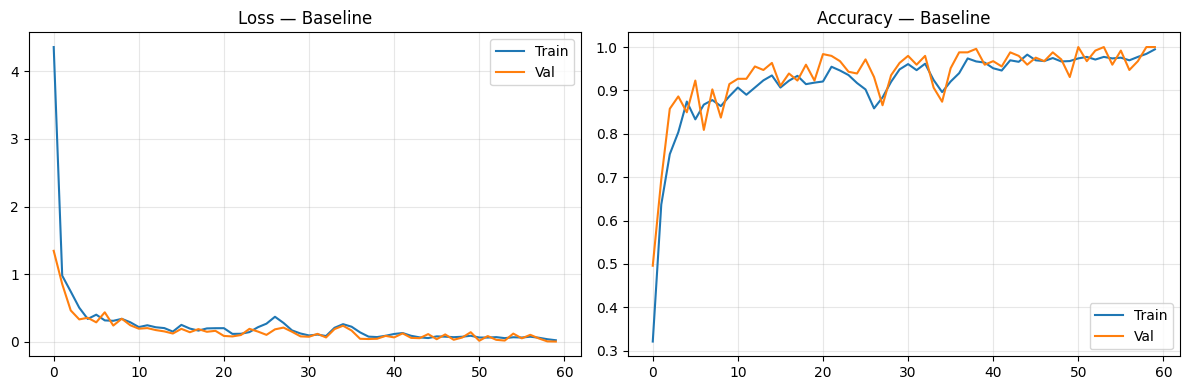

In [13]:
print("=" * 60)
print("EXPERIMENT 1: Baseline MLP [512, 256]")
print("=" * 60)

baseline_model = MLP(input_dim, [512, 256], num_classes)
baseline_hist = train_model(baseline_model, epochs=EPOCHS)

# evaluate on test
criterion = nn.CrossEntropyLoss()
_, test_acc, preds, labels = evaluate(baseline_model, test_loader, criterion)
test_f1 = f1_score(labels, preds, average="macro")
print(f"\n  Test Accuracy: {test_acc:.4f}   Macro F1: {test_f1:.4f}")

plot_history(baseline_hist, "— Baseline")

## 6. Experiment 2 — Activation Functions

Compare ReLU, Sigmoid, and Tanh.

**Why?** Sigmoid and Tanh suffer from vanishing gradients — their derivatives approach 0 for large inputs, making it hard for gradients to flow through deep layers. ReLU doesn't saturate for positive values (gradient = 1), so it trains faster.

In [14]:
activation_results = {}

for act in ["relu", "sigmoid", "tanh"]:
    print(f"\n{'='*60}")
    print(f"Training with activation: {act}")
    print(f"{'='*60}")
    
    model = MLP(input_dim, [512, 256], num_classes, activation=act)
    hist = train_model(model, epochs=EPOCHS)
    
    _, acc, p, l = evaluate(model, test_loader, criterion)
    f1 = f1_score(l, p, average="macro")
    print(f"  Test Acc: {acc:.4f}   F1: {f1:.4f}")
    
    activation_results[act] = {"hist": hist, "acc": acc, "f1": f1}


Training with activation: relu
  Epoch   1  train_loss=4.7553  val_loss=1.2713  train_acc=0.332  val_acc=0.549
  Epoch  10  train_loss=0.3167  val_loss=0.8379  train_acc=0.869  val_acc=0.764
  Epoch  20  train_loss=0.3645  val_loss=0.1407  train_acc=0.869  val_acc=0.939
  Epoch  30  train_loss=0.0837  val_loss=0.0937  train_acc=0.964  val_acc=0.963
  Epoch  40  train_loss=0.1324  val_loss=0.0536  train_acc=0.945  val_acc=0.984
  Early stopping at epoch 42
  Test Acc: 0.9756   F1: 0.9755

Training with activation: sigmoid
  Epoch   1  train_loss=2.1630  val_loss=1.9671  train_acc=0.236  val_acc=0.362
  Epoch  10  train_loss=0.8804  val_loss=0.8850  train_acc=0.649  val_acc=0.581
  Epoch  20  train_loss=0.7735  val_loss=0.7305  train_acc=0.630  val_acc=0.683
  Epoch  30  train_loss=0.6798  val_loss=0.6382  train_acc=0.686  val_acc=0.793
  Epoch  40  train_loss=0.7437  val_loss=0.7496  train_acc=0.674  val_acc=0.630
  Early stopping at epoch 40
  Test Acc: 0.7886   F1: 0.7242

Training w

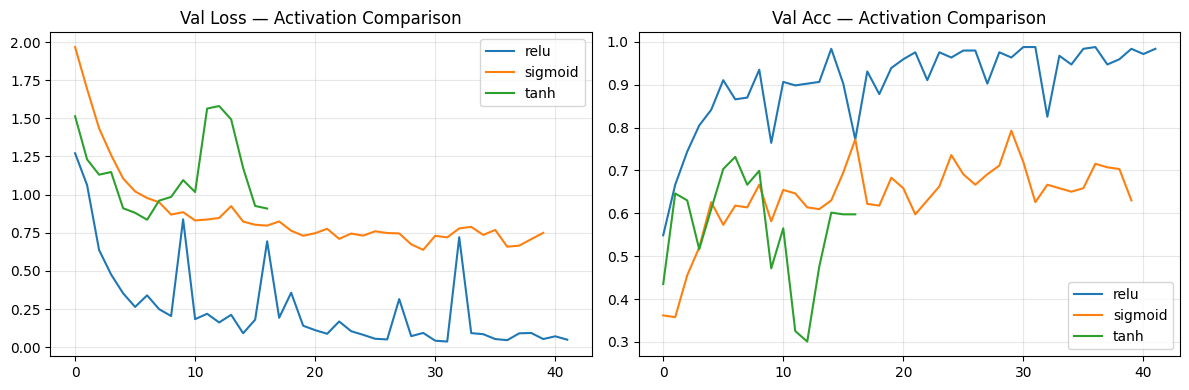


Summary:
  relu      acc=0.9756  f1=0.9755
  sigmoid   acc=0.7886  f1=0.7242
  tanh      acc=0.7195  f1=0.6630


In [15]:
# plot all activations together
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for act, res in activation_results.items():
    ax1.plot(res["hist"]["val_loss"], label=act)
    ax2.plot(res["hist"]["val_acc"], label=act)

ax1.set_title("Val Loss — Activation Comparison"); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_title("Val Acc — Activation Comparison"); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/mlp/activation_comparison.png", dpi=150)
plt.show()

print("\nSummary:")
for act, res in activation_results.items():
    print(f"  {act:8s}  acc={res['acc']:.4f}  f1={res['f1']:.4f}")

## 7. Experiment 3 — Depth vs Width

Compare architectures with different depths and widths.

**Why?** This demonstrates the capacity / bias-variance tradeoff. A shallow network might underfit (high bias), while a very deep one might overfit (high variance). We want to find the sweet spot.

In [16]:
architectures = {
    "Shallow [1024]":         [1024],
    "Medium [512,256]":       [512, 256],
    "Deep [512,256,128]":     [512, 256, 128],
    "VDeep [512,256,128,64]": [512, 256, 128, 64],
}

arch_results = {}
for name, layers in architectures.items():
    print(f"\n{'='*60}")
    print(f"Architecture: {name}")
    print(f"{'='*60}")
    
    model = MLP(input_dim, layers, num_classes)
    hist = train_model(model, epochs=EPOCHS)
    
    _, acc, p, l = evaluate(model, test_loader, criterion)
    f1 = f1_score(l, p, average="macro")
    n_params = sum(par.numel() for par in model.parameters())
    print(f"  Params: {n_params:,}   Test Acc: {acc:.4f}   F1: {f1:.4f}")
    
    arch_results[name] = {"hist": hist, "acc": acc, "f1": f1, "params": n_params}


Architecture: Shallow [1024]
  Epoch   1  train_loss=14.5939  val_loss=4.1323  train_acc=0.363  val_acc=0.606
  Epoch  10  train_loss=0.2664  val_loss=0.3109  train_acc=0.882  val_acc=0.898
  Epoch  20  train_loss=0.1724  val_loss=0.1015  train_acc=0.925  val_acc=0.984
  Epoch  30  train_loss=0.1166  val_loss=0.1561  train_acc=0.956  val_acc=0.927
  Epoch  40  train_loss=0.1121  val_loss=0.2318  train_acc=0.957  val_acc=0.923
  Epoch  50  train_loss=0.1131  val_loss=0.1652  train_acc=0.962  val_acc=0.919
  Early stopping at epoch 54
  Params: 201,338,891   Test Acc: 0.9837   F1: 0.9836

Architecture: Medium [512,256]
  Epoch   1  train_loss=4.8110  val_loss=1.0161  train_acc=0.339  val_acc=0.650
  Epoch  10  train_loss=0.2218  val_loss=0.2802  train_acc=0.907  val_acc=0.915
  Epoch  20  train_loss=0.1503  val_loss=0.1636  train_acc=0.935  val_acc=0.923
  Epoch  30  train_loss=0.1683  val_loss=0.7988  train_acc=0.933  val_acc=0.744
  Early stopping at epoch 38
  Params: 100,797,963   T

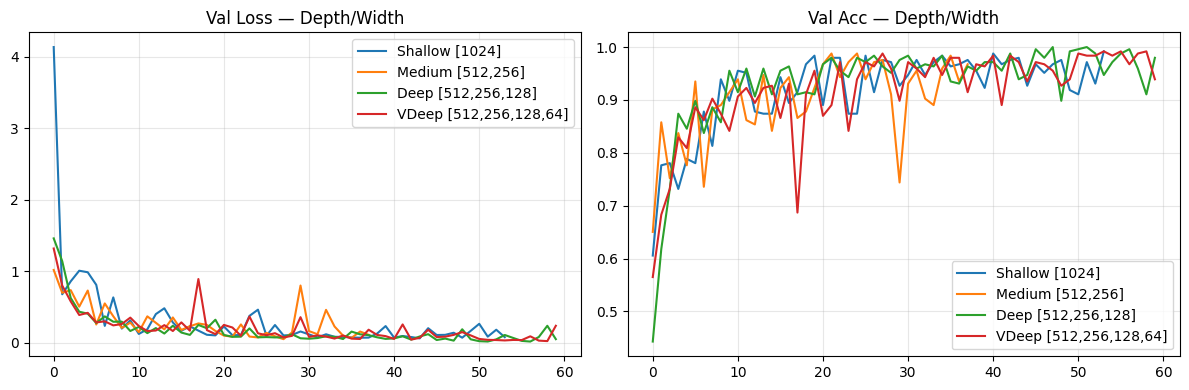


Summary:
  Shallow [1024]             params=201,338,891  acc=0.9837  f1=0.9836
  Medium [512,256]           params=100,797,963  acc=0.9634  f1=0.9636
  Deep [512,256,128]         params=100,829,451  acc=0.9919  f1=0.9919
  VDeep [512,256,128,64]     params=100,837,003  acc=0.9837  f1=0.9838


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for name, res in arch_results.items():
    ax1.plot(res["hist"]["val_loss"], label=name)
    ax2.plot(res["hist"]["val_acc"], label=name)
ax1.set_title("Val Loss — Depth/Width"); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_title("Val Acc — Depth/Width"); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/mlp/depth_width_comparison.png", dpi=150)
plt.show()

print("\nSummary:")
for name, res in arch_results.items():
    print(f"  {name:25s}  params={res['params']:>10,}  acc={res['acc']:.4f}  f1={res['f1']:.4f}")

## 8. Experiment 4 — L2 Regularization / Weight Decay

L2 adds a penalty alpha * ||w||^2 to the loss. This shrinks all weights toward zero, preventing any single weight from becoming too large.

In the optimizer this is the `weight_decay` parameter — every step multiplies weights by `(1 - lr * wd)` before the gradient update.

In [18]:
l2_results = {}

for wd in [0, 1e-4, 1e-3, 1e-2]:
    print(f"\n{'='*60}")
    print(f"L2 weight_decay = {wd}")
    print(f"{'='*60}")
    
    model = MLP(input_dim, [512, 256], num_classes)
    hist = train_model(model, epochs=EPOCHS, weight_decay=wd)
    
    _, acc, p, l = evaluate(model, test_loader, criterion)
    f1 = f1_score(l, p, average="macro")
    print(f"  Test Acc: {acc:.4f}   F1: {f1:.4f}")
    
    l2_results[f"wd={wd}"] = {"hist": hist, "acc": acc, "f1": f1}


L2 weight_decay = 0
  Epoch   1  train_loss=5.4512  val_loss=1.4907  train_acc=0.309  val_acc=0.545
  Epoch  10  train_loss=0.3025  val_loss=0.2302  train_acc=0.878  val_acc=0.902
  Epoch  20  train_loss=0.1557  val_loss=0.2054  train_acc=0.939  val_acc=0.878
  Epoch  30  train_loss=0.2741  val_loss=0.3129  train_acc=0.894  val_acc=0.886
  Epoch  40  train_loss=0.1000  val_loss=0.0683  train_acc=0.958  val_acc=0.972
  Epoch  50  train_loss=0.1413  val_loss=0.2939  train_acc=0.949  val_acc=0.882
  Early stopping at epoch 57
  Test Acc: 0.9878   F1: 0.9879

L2 weight_decay = 0.0001
  Epoch   1  train_loss=5.1746  val_loss=1.3481  train_acc=0.318  val_acc=0.545
  Epoch  10  train_loss=0.5516  val_loss=0.3902  train_acc=0.818  val_acc=0.813
  Epoch  20  train_loss=0.2503  val_loss=0.3598  train_acc=0.907  val_acc=0.850
  Epoch  30  train_loss=0.2232  val_loss=0.1436  train_acc=0.914  val_acc=0.947
  Epoch  40  train_loss=0.0845  val_loss=0.0692  train_acc=0.967  val_acc=0.972
  Early stop

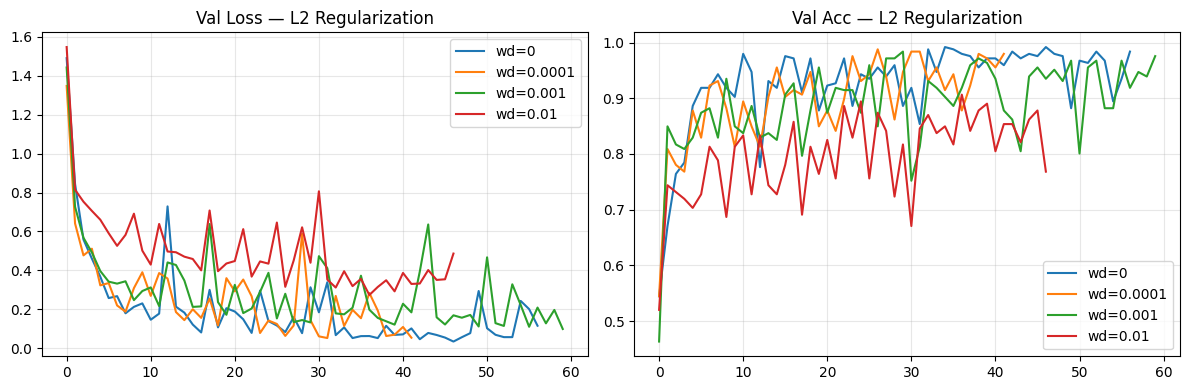

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for name, res in l2_results.items():
    ax1.plot(res["hist"]["val_loss"], label=name)
    ax2.plot(res["hist"]["val_acc"], label=name)
ax1.set_title("Val Loss — L2 Regularization"); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_title("Val Acc — L2 Regularization"); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/mlp/l2_comparison.png", dpi=150)
plt.show()

## 9. Experiment 5 — Dropout

Dropout randomly zeroes out neurons during training with probability `p`. This forces the network to not rely on any single neuron — like training an ensemble of smaller networks.

At test time, all neurons are active but outputs are scaled by `(1-p)` (PyTorch handles this automatically with inverted dropout).

In [20]:
dropout_results = {}

for dp in [0.0, 0.2, 0.3, 0.5]:
    print(f"\n{'='*60}")
    print(f"Dropout p = {dp}")
    print(f"{'='*60}")
    
    model = MLP(input_dim, [512, 256], num_classes, dropout=dp)
    hist = train_model(model, epochs=EPOCHS)
    
    _, acc, p_, l = evaluate(model, test_loader, criterion)
    f1 = f1_score(l, p_, average="macro")
    print(f"  Test Acc: {acc:.4f}   F1: {f1:.4f}")
    
    dropout_results[f"p={dp}"] = {"hist": hist, "acc": acc, "f1": f1}


Dropout p = 0.0
  Epoch   1  train_loss=4.4823  val_loss=1.1488  train_acc=0.339  val_acc=0.630
  Epoch  10  train_loss=0.3158  val_loss=0.3195  train_acc=0.872  val_acc=0.882
  Epoch  20  train_loss=0.1455  val_loss=0.2152  train_acc=0.941  val_acc=0.890
  Epoch  30  train_loss=0.1026  val_loss=0.0815  train_acc=0.958  val_acc=0.967
  Epoch  40  train_loss=0.1129  val_loss=0.0601  train_acc=0.953  val_acc=0.967
  Early stopping at epoch 45
  Test Acc: 0.9919   F1: 0.9919

Dropout p = 0.2
  Epoch   1  train_loss=4.8294  val_loss=1.2462  train_acc=0.252  val_acc=0.671
  Epoch  10  train_loss=0.4249  val_loss=0.2842  train_acc=0.825  val_acc=0.862
  Epoch  20  train_loss=0.3996  val_loss=0.2088  train_acc=0.849  val_acc=0.894
  Epoch  30  train_loss=0.3402  val_loss=0.1616  train_acc=0.852  val_acc=0.911
  Epoch  40  train_loss=0.6108  val_loss=0.4825  train_acc=0.791  val_acc=0.837
  Early stopping at epoch 43
  Test Acc: 0.9146   F1: 0.9058

Dropout p = 0.3
  Epoch   1  train_loss=4.3

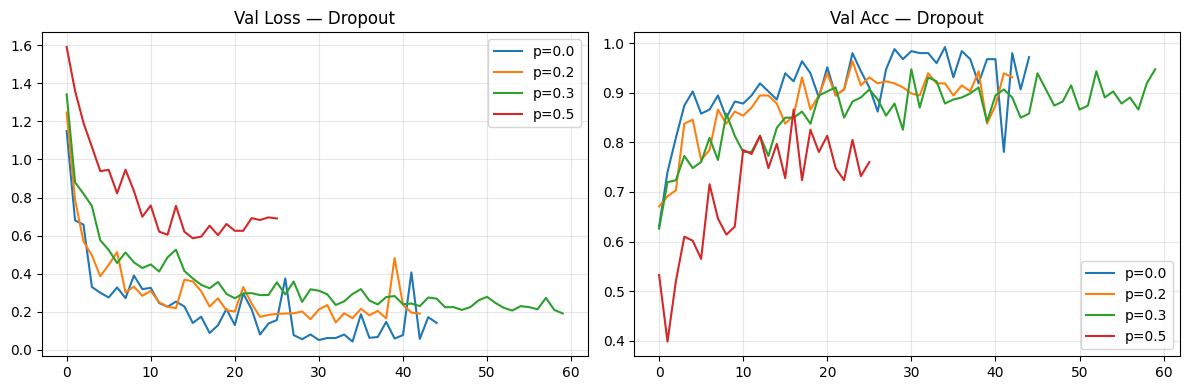

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for name, res in dropout_results.items():
    ax1.plot(res["hist"]["val_loss"], label=name)
    ax2.plot(res["hist"]["val_acc"], label=name)
ax1.set_title("Val Loss — Dropout"); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_title("Val Acc — Dropout"); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/mlp/dropout_comparison.png", dpi=150)
plt.show()

## 10. Experiment 6 — Batch Normalization

Batch Norm normalizes each layer's input using the mini-batch mean and variance. This reduces internal covariate shift, allows higher learning rates, and acts as a mild regularizer.

Batch Normalization
  Epoch   1  train_loss=1.6489  val_loss=1.3504  train_acc=0.442  val_acc=0.581
  Epoch  10  train_loss=0.2622  val_loss=0.1839  train_acc=0.909  val_acc=0.955
  Epoch  20  train_loss=0.1844  val_loss=0.1199  train_acc=0.935  val_acc=0.951
  Epoch  30  train_loss=0.1211  val_loss=0.0734  train_acc=0.957  val_acc=0.980
  Epoch  40  train_loss=0.0755  val_loss=0.0460  train_acc=0.976  val_acc=1.000
  Early stopping at epoch 49

  Test Acc: 0.9959   F1: 0.9960


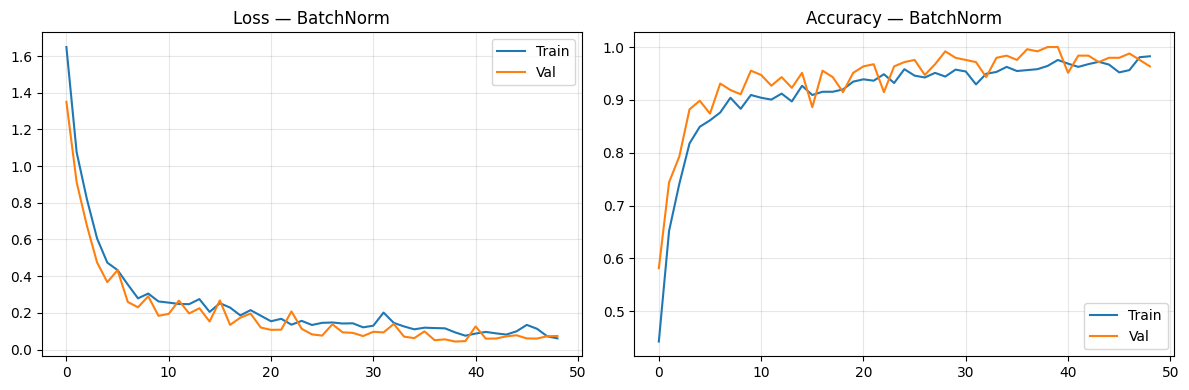

In [22]:
print("=" * 60)
print("Batch Normalization")
print("=" * 60)

bn_model = MLP(input_dim, [512, 256], num_classes, use_bn=True)
bn_hist = train_model(bn_model, epochs=EPOCHS)

_, bn_acc, bn_p, bn_l = evaluate(bn_model, test_loader, criterion)
bn_f1 = f1_score(bn_l, bn_p, average="macro")
print(f"\n  Test Acc: {bn_acc:.4f}   F1: {bn_f1:.4f}")

plot_history(bn_hist, "— BatchNorm")

## 11. Experiment 7 — Optimizer Comparison

Compare how different optimizers converge:
- **SGD**: basic gradient descent, can be slow
- **SGD + Momentum**: adds velocity to smooth out noisy gradients
- **Adam**: adaptive learning rates per parameter, usually converges fastest

In [23]:
optimizer_configs = [
    ("SGD",          "sgd",          0.01),
    ("SGD+Momentum", "sgd_momentum", 0.01),
    ("Adam",         "adam",          0.001),
]

opt_results = {}
for name, opt_type, lr in optimizer_configs:
    print(f"\n{'='*60}")
    print(f"Optimizer: {name} (lr={lr})")
    print(f"{'='*60}")
    
    model = MLP(input_dim, [512, 256], num_classes)
    hist = train_model(model, epochs=EPOCHS, lr=lr, optimizer_type=opt_type)
    
    _, acc, p_, l = evaluate(model, test_loader, criterion)
    f1 = f1_score(l, p_, average="macro")
    print(f"  Test Acc: {acc:.4f}   F1: {f1:.4f}")
    
    opt_results[name] = {"hist": hist, "acc": acc, "f1": f1}


Optimizer: SGD (lr=0.01)
  Epoch   1  train_loss=1.9981  val_loss=1.6844  train_acc=0.286  val_acc=0.374
  Epoch  10  train_loss=0.5588  val_loss=0.7411  train_acc=0.787  val_acc=0.667
  Epoch  20  train_loss=0.4001  val_loss=0.2806  train_acc=0.854  val_acc=0.902
  Epoch  30  train_loss=0.2499  val_loss=0.1800  train_acc=0.901  val_acc=0.951
  Epoch  40  train_loss=0.1992  val_loss=0.2126  train_acc=0.929  val_acc=0.898
  Epoch  50  train_loss=0.1492  val_loss=0.1415  train_acc=0.948  val_acc=0.939
  Epoch  60  train_loss=0.1380  val_loss=0.0863  train_acc=0.951  val_acc=0.972
  Test Acc: 0.9797   F1: 0.9796

Optimizer: SGD+Momentum (lr=0.01)
  Epoch   1  train_loss=1.7059  val_loss=1.0121  train_acc=0.373  val_acc=0.618
  Epoch  10  train_loss=0.3558  val_loss=0.2541  train_acc=0.861  val_acc=0.866
  Epoch  20  train_loss=0.2833  val_loss=0.1688  train_acc=0.883  val_acc=0.919
  Epoch  30  train_loss=0.3251  val_loss=0.2529  train_acc=0.873  val_acc=0.886
  Early stopping at epoch 3

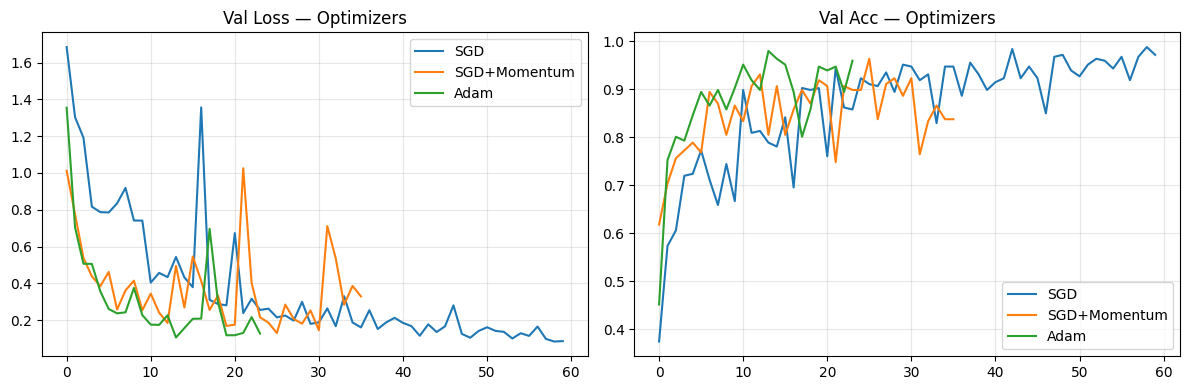

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for name, res in opt_results.items():
    ax1.plot(res["hist"]["val_loss"], label=name)
    ax2.plot(res["hist"]["val_acc"], label=name)
ax1.set_title("Val Loss — Optimizers"); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_title("Val Acc — Optimizers"); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/mlp/optimizer_comparison.png", dpi=150)
plt.show()

## 12. Experiment 8 — Best Combination

Combine the best settings from all experiments above: deeper architecture + batch norm + Adam.

BEST COMBO: [512, 256, 128] + BN
  Epoch   1  train_loss=1.5061  val_loss=1.1770  train_acc=0.524  val_acc=0.764
  Epoch  10  train_loss=0.2724  val_loss=0.1986  train_acc=0.897  val_acc=0.947
  Epoch  20  train_loss=0.2063  val_loss=0.2581  train_acc=0.914  val_acc=0.894
  Epoch  30  train_loss=0.1529  val_loss=0.1948  train_acc=0.942  val_acc=0.915
  Epoch  40  train_loss=0.1366  val_loss=0.0915  train_acc=0.956  val_acc=0.972
  Epoch  50  train_loss=0.0745  val_loss=0.0417  train_acc=0.976  val_acc=0.996
  Epoch  60  train_loss=0.0895  val_loss=0.0387  train_acc=0.968  val_acc=0.984
  Epoch  70  train_loss=0.0577  val_loss=0.0350  train_acc=0.981  val_acc=0.988
  Epoch  80  train_loss=0.0544  val_loss=0.0203  train_acc=0.979  val_acc=1.000

  Test Accuracy: 1.0000   Macro F1: 1.0000


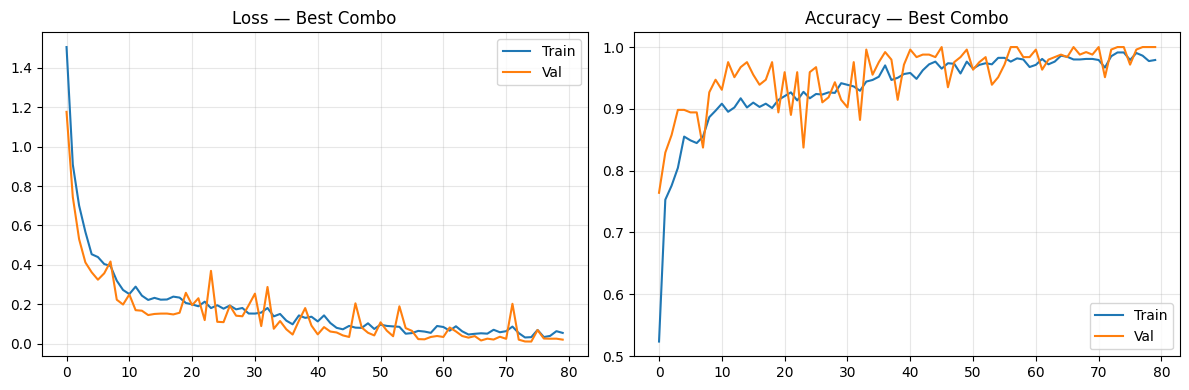

In [27]:
print("=" * 60)
print("BEST COMBO: [512, 256, 128] + BN")
print("=" * 60)

best_model = MLP(input_dim, [512, 256, 128], num_classes, use_bn=True)
best_hist = train_model(best_model, epochs=80, patience=15)

_, best_acc, best_preds, best_labels = evaluate(best_model, test_loader, criterion)
best_f1 = f1_score(best_labels, best_preds, average="macro")
print(f"\n  Test Accuracy: {best_acc:.4f}   Macro F1: {best_f1:.4f}")

plot_history(best_hist, "— Best Combo")

## 13. Results & Analysis

In [28]:
# classification report
print(classification_report(best_labels, best_preds, target_names=class_names, digits=3))

              precision    recall  f1-score   support

       Earth      1.000     1.000     1.000        22
     Jupiter      1.000     1.000     1.000        22
    MakeMake      1.000     1.000     1.000        22
        Mars      1.000     1.000     1.000        23
     Mercury      1.000     1.000     1.000        23
        Moon      1.000     1.000     1.000        22
     Neptune      1.000     1.000     1.000        23
       Pluto      1.000     1.000     1.000        22
      Saturn      1.000     1.000     1.000        23
      Uranus      1.000     1.000     1.000        22
       Venus      1.000     1.000     1.000        22

    accuracy                          1.000       246
   macro avg      1.000     1.000     1.000       246
weighted avg      1.000     1.000     1.000       246



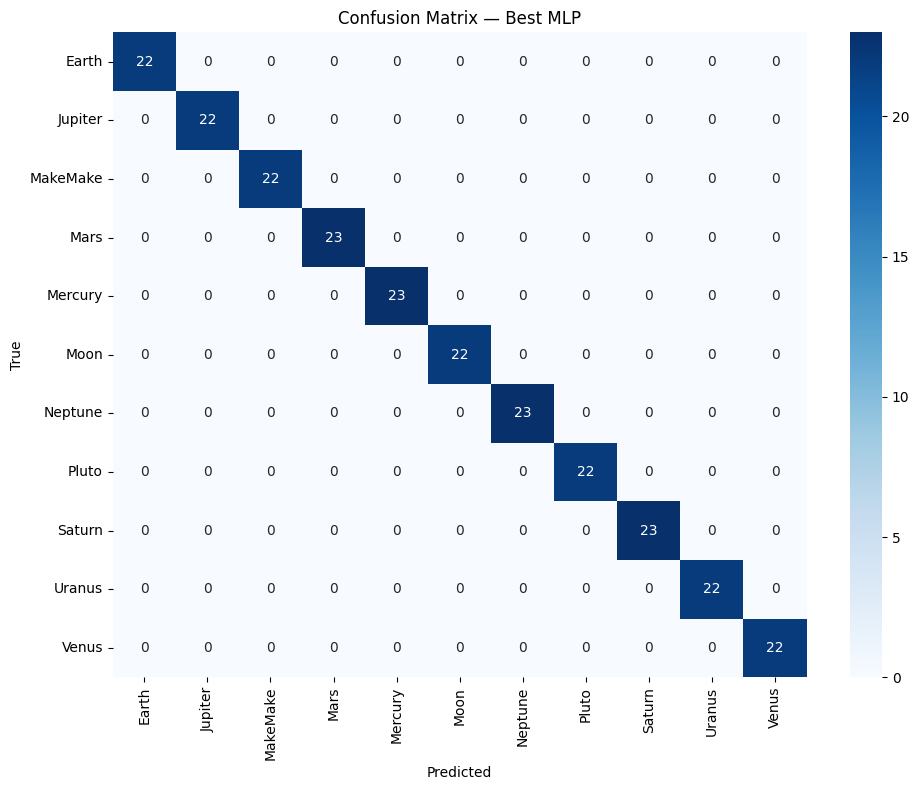

In [29]:
# confusion matrix
cm = confusion_matrix(best_labels, best_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Best MLP")
plt.tight_layout()
plt.savefig("../results/mlp/confusion_matrix.png", dpi=150)
plt.show()

In [30]:
# bias analysis — which classes get confused most?
print("Most confused pairs:")
print("-" * 50)

cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)

for _ in range(5):
    idx = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
    if cm_copy[idx] == 0:
        break
    print(f"  {class_names[idx[0]]:12s} -> {class_names[idx[1]]:12s}  ({cm_copy[idx]} samples)")
    cm_copy[idx] = 0

Most confused pairs:
--------------------------------------------------


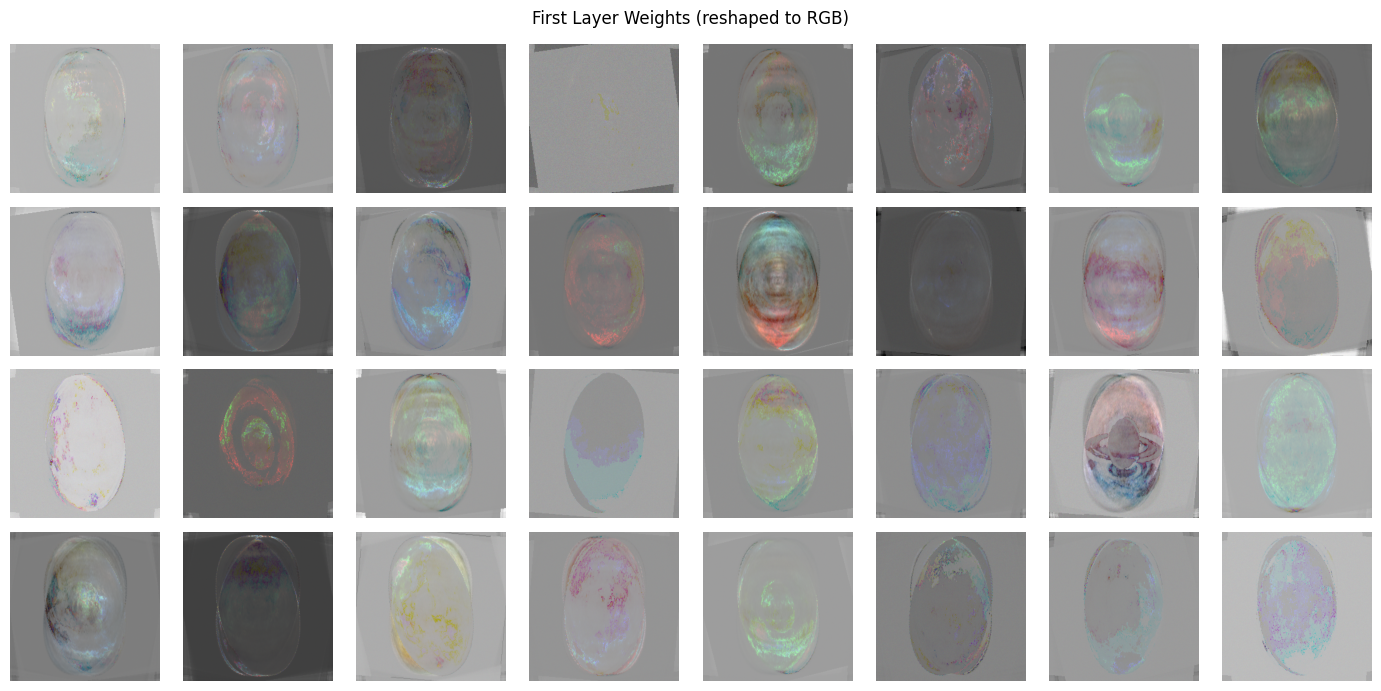

In [31]:
# visualize first layer weights
# each neuron in the first layer has weights of shape (3*256*256,)
# reshape back to 256x256 RGB to see what patterns the MLP looks for

w = list(best_model.parameters())[0].detach().cpu().numpy()  # shape: [512, 196608]

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i < w.shape[0]:
        patch = w[i].reshape(3, IMG_SIZE, IMG_SIZE).transpose(1, 2, 0)
        patch = (patch - patch.min()) / (patch.max() - patch.min() + 1e-8)
        ax.imshow(patch)
    ax.axis("off")
plt.suptitle("First Layer Weights (reshaped to RGB)")
plt.tight_layout()
plt.savefig("../results/mlp/first_layer_weights.png", dpi=150)
plt.show()

## 14. Summary Table

In [32]:
# collect all results into a summary
summary = []

# baseline
_, baseline_acc_f, bp, bl = evaluate(baseline_model, test_loader, criterion)
summary.append({"name": "Baseline [512,256]", "acc": baseline_acc_f, "f1": f1_score(bl, bp, average="macro")})

# activations
for act, res in activation_results.items():
    summary.append({"name": f"Act={act}", "acc": res["acc"], "f1": res["f1"]})

# architectures
for name, res in arch_results.items():
    summary.append({"name": name, "acc": res["acc"], "f1": res["f1"]})

# L2
for name, res in l2_results.items():
    summary.append({"name": f"L2 {name}", "acc": res["acc"], "f1": res["f1"]})

# dropout
for name, res in dropout_results.items():
    summary.append({"name": f"Dropout {name}", "acc": res["acc"], "f1": res["f1"]})

# batchnorm
summary.append({"name": "BatchNorm", "acc": bn_acc, "f1": bn_f1})

# optimizers
for name, res in opt_results.items():
    summary.append({"name": f"Opt={name}", "acc": res["acc"], "f1": res["f1"]})

# best combo
summary.append({"name": "Best Combo", "acc": best_acc, "f1": best_f1})

# print table
print(f"{'Experiment':<30s}  {'Acc':>7s}  {'F1':>7s}")
print("-" * 50)
for s in summary:
    print(f"{s['name']:<30s}  {s['acc']:7.4f}  {s['f1']:7.4f}")

Experiment                          Acc       F1
--------------------------------------------------
Baseline [512,256]               1.0000   1.0000
Act=relu                         0.9756   0.9755
Act=sigmoid                      0.7886   0.7242
Act=tanh                         0.7195   0.6630
Shallow [1024]                   0.9837   0.9836
Medium [512,256]                 0.9634   0.9636
Deep [512,256,128]               0.9919   0.9919
VDeep [512,256,128,64]           0.9837   0.9838
L2 wd=0                          0.9878   0.9879
L2 wd=0.0001                     0.9593   0.9579
L2 wd=0.001                      0.9593   0.9599
L2 wd=0.01                       0.9146   0.9081
Dropout p=0.0                    0.9919   0.9919
Dropout p=0.2                    0.9146   0.9058
Dropout p=0.3                    0.9106   0.9109
Dropout p=0.5                    0.7561   0.7005
BatchNorm                        0.9959   0.9960
Opt=SGD                          0.9797   0.9796
Opt=SGD+Momentum  

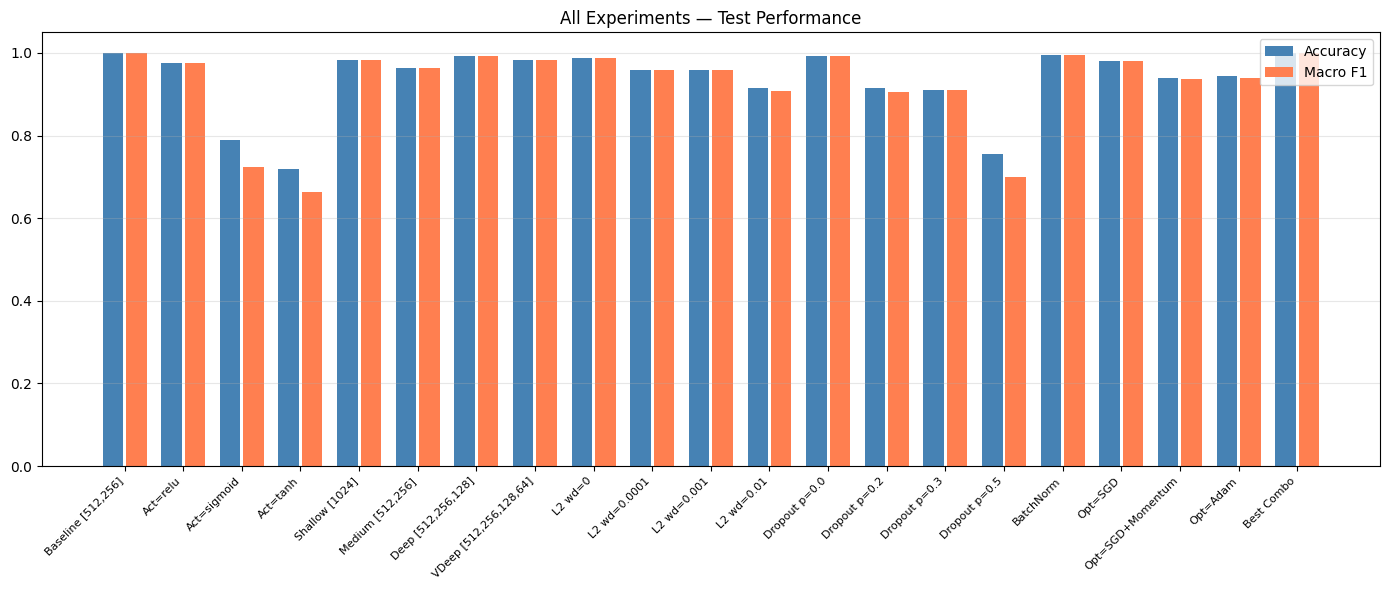

In [33]:
# bar chart
names = [s["name"] for s in summary]
accs = [s["acc"] for s in summary]
f1s = [s["f1"] for s in summary]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - 0.2, accs, 0.35, label="Accuracy", color="steelblue")
ax.bar(x + 0.2, f1s, 0.35, label="Macro F1", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title("All Experiments — Test Performance")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../results/mlp/all_experiments_comparison.png", dpi=150)
plt.show()

## 15. Save Model & Results

In [34]:
# save best model
torch.save({
    "model_state_dict": best_model.state_dict(),
    "class_names": class_names,
    "num_classes": num_classes,
    "img_size": IMG_SIZE,
    "hidden_layers": [512, 256, 128],
    "test_acc": best_acc,
    "test_f1": best_f1,
}, "../models/mlp/best_mlp.pth")

print("Model saved to ../models/mlp/best_mlp.pth")

Model saved to ../models/mlp/best_mlp.pth


In [36]:
# save results json
with open("../results/mlp/mlp_results.json", "w") as f:
    json.dump(summary, f, indent=2)

# save classification report
report = classification_report(best_labels, best_preds, target_names=class_names, digits=3)
with open("../results/mlp/classification_report.txt", "w") as f:
    f.write(report)

print("Results saved to ../results/mlp/")

Results saved to ../results/mlp/
